# Práctica 4 – Análisis de Convergencia de Algoritmos de Optimización
### Redes Neuronales Artificiales y Aprendizaje Profundo
**José Luis Haro Díaz**

## Importar librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

print('NumPy version:', np.__version__)
print('Todas las librerías cargadas correctamente ✓')

NumPy version: 2.0.2
Todas las librerías cargadas correctamente ✓


## Cargar y preparar MNIST

In [2]:
try:
    import tensorflow as tf
    (x_train_raw, _), (x_test_raw, _) = tf.keras.datasets.mnist.load_data()
    print('MNIST cargado via TensorFlow/Keras')
except ImportError:
    import urllib.request, gzip, os
    base = 'http://yann.lecun.com/exdb/mnist/'
    files = ['train-images-idx3-ubyte.gz', 't10k-images-idx3-ubyte.gz']
    def load_images(path):
        with gzip.open(path, 'rb') as f:
            data = np.frombuffer(f.read(), np.uint8, offset=16)
        return data.reshape(-1, 28, 28)
    for fname in files:
        if not os.path.exists(fname):
            urllib.request.urlretrieve(base + fname, fname)
    x_train_raw = load_images(files[0])
    x_test_raw  = load_images(files[1])
    print('MNIST descargado y cargado manualmente')

x_train = x_train_raw.astype('float32').reshape(-1, 784) / 255.0
x_test  = x_test_raw.astype('float32').reshape(-1, 784)  / 255.0

#reducir conjunto de entrenamiento para entrenar los 5 modelos en tiempo razonable
N_TRAIN = 10000   #muestras de entrenamiento por optimizador
N_TEST  = 2000    #muestras de validación
x_train = x_train[:N_TRAIN]
x_test  = x_test[:N_TEST]

print(f'Train: {x_train.shape}  |  Test: {x_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
MNIST cargado via TensorFlow/Keras
Train: (10000, 784)  |  Test: (2000, 784)


## Agregar ruido gaussiano

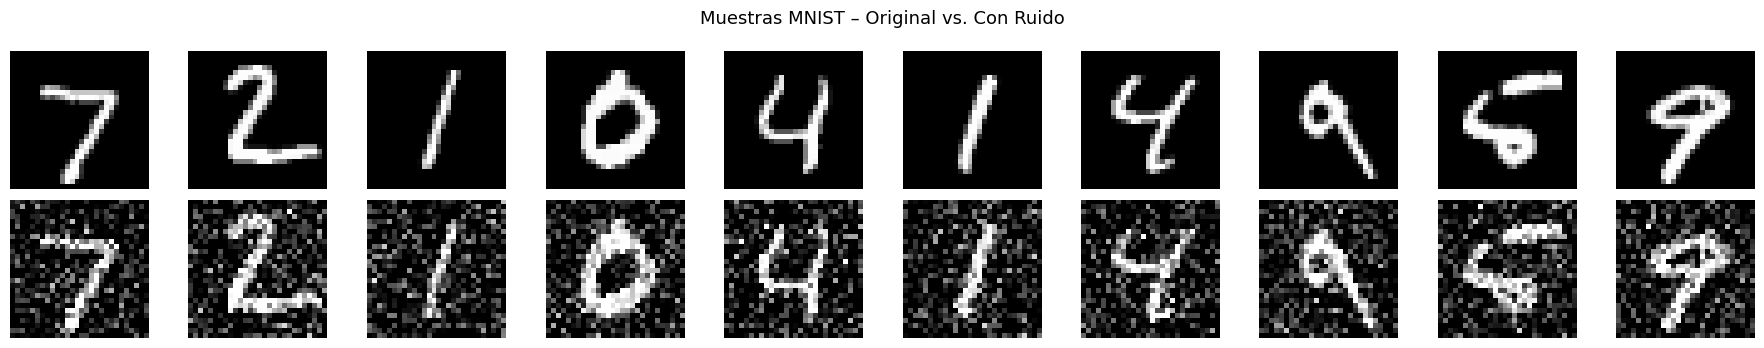

In [3]:
def add_noise(images, noise_factor=0.3, seed=None):
    """Añade ruido gaussiano y recorta valores a [0, 1]."""
    rng = np.random.default_rng(seed)
    noisy = images + noise_factor * rng.standard_normal(images.shape)
    return np.clip(noisy, 0.0, 1.0).astype('float32')

NOISE_FACTOR = 0.3
x_train_noisy = add_noise(x_train, NOISE_FACTOR, seed=0)
x_test_noisy  = add_noise(x_test,  NOISE_FACTOR, seed=1)

#Visualizar algunos ejemplos
fig, axes = plt.subplots(2, 10, figsize=(18, 3.5))
for i in range(10):
    axes[0, i].imshow(x_test[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_test_noisy[i].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
    axes[1, i].axis('off')
axes[0, 0].set_ylabel('Original', fontsize=10, rotation=0, labelpad=55, va='center')
axes[1, 0].set_ylabel('Con ruido', fontsize=10, rotation=0, labelpad=55, va='center')
plt.suptitle('Muestras MNIST – Original vs. Con Ruido', fontsize=13)
plt.tight_layout()
plt.show()

## Red neuronal implementada desde cero (NumPy puro)

In [5]:
#Funciones de activación
def relu(x):
    return np.maximum(0.0, x)

def relu_grad(x):
    return (x > 0).astype('float32')

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -500, 500)))

def sigmoid_grad(x):
    s = sigmoid(x)
    return s * (1.0 - s)

def he_init(fan_in, fan_out):
    std = np.sqrt(2.0 / fan_in)
    return (np.random.randn(fan_in, fan_out) * std).astype('float32')

class DenoisingAutoencoderNumpy:

    def __init__(self, seed=42):
        np.random.seed(seed)
        #Pesos: W[i] es la matriz de la capa i, b[i] su sesgo
        self.W = [
            he_init(784, 256),
            he_init(256, 128),
            he_init(128,  64),
            he_init( 64, 128),
            he_init(128, 256),
            he_init(256, 784),
        ]
        self.b = [np.zeros((1, d), dtype='float32')
                  for d in [256, 128, 64, 128, 256, 784]]

    def forward(self, X):
        cache = {}
        A = X
        activations = [relu, relu, relu, relu, relu, sigmoid]

        for i, (W, b, act) in enumerate(zip(self.W, self.b, activations)):
            Z = A @ W + b
            A = act(Z)
            cache[f'Z{i}'] = Z
            cache[f'A{i}'] = A

        cache['input'] = X
        return A, cache

    def backward(self, cache, y_true):
        m = y_true.shape[0]
        grad_W = [None] * 6
        grad_b = [None] * 6

        act_grads = [relu_grad, relu_grad, relu_grad,
                     relu_grad, relu_grad, sigmoid_grad]

        dA = 2.0 * (cache['A5'] - y_true) / m

        for i in reversed(range(6)):
            Z = cache[f'Z{i}']
            A_prev = cache[f'A{i-1}'] if i > 0 else cache['input']

            dZ = dA * act_grads[i](Z)
            grad_W[i] = A_prev.T @ dZ
            grad_b[i] = dZ.sum(axis=0, keepdims=True)
            dA = dZ @ self.W[i].T

        return grad_W, grad_b

    def mse_loss(self, y_pred, y_true):
        return np.mean((y_pred - y_true) ** 2)

    def predict(self, X):
        out, _ = self.forward(X)
        return out


print('Clase DenoisingAutoencoderNumpy definida')
# Prueba rápida de dimensiones
_test_model = DenoisingAutoencoderNumpy()
_out, _cache = _test_model.forward(x_train[:4])
print(f'  Input shape:  {x_train[:4].shape}')
print(f'  Output shape: {_out.shape}') #debe ser igual al input

Clase DenoisingAutoencoderNumpy definida
  Input shape:  (4, 784)
  Output shape: (4, 784)


## Implementación manual de los 5 optimizadores

In [8]:
#Optimizador 1: Gradiente Descendente Estocástico (SGD puro)
class SGD:
    """Gradiente Descendente Estocástico clásico.

    Regla de actualización:
        θ ← θ - η · ∇L(θ)

    Parámetros:
        lr (float): Tasa de aprendizaje η.
    """
    def __init__(self, lr=0.01):
        self.lr = lr

    def step(self, params_W, params_b, grads_W, grads_b):
        for i in range(len(params_W)):
            params_W[i] -= self.lr * grads_W[i]
            params_b[i] -= self.lr * grads_b[i]


#Optimizador 2: Momentum
class Momentum:
    """SGD con Momento

    Acumula una velocidad exponencialmente ponderada de los gradientes pasados,
    lo que acelera el aprendizaje en direcciones consistentes y amortigua
    oscilaciones.

    Reglas de actualización:
        v_t = β · v_{t-1} + η · ∇L(θ_{t-1})
        θ_t = θ_{t-1} - v_t

    Parámetros:
        lr   (float): Tasa de aprendizaje η.
        beta (float): Factor de momento β  (típicamente 0.9).
    """
    def __init__(self, lr=0.01, beta=0.9):
        self.lr   = lr
        self.beta = beta
        self.vW   = None
        self.vb   = None

    def _init_velocities(self, params_W, params_b):
        self.vW = [np.zeros_like(W) for W in params_W]
        self.vb = [np.zeros_like(b) for b in params_b]

    def step(self, params_W, params_b, grads_W, grads_b):
        if self.vW is None:
            self._init_velocities(params_W, params_b)

        for i in range(len(params_W)):
            self.vW[i] = self.beta * self.vW[i] + self.lr * grads_W[i]
            self.vb[i] = self.beta * self.vb[i] + self.lr * grads_b[i]
            params_W[i] -= self.vW[i]
            params_b[i] -= self.vb[i]


# Optimizador 3: Nesterov Accelerated Gradient (NAG)
class Nesterov:
    """Gradiente de Nesterov (NAG)

    Evalúa el gradiente en la posición "anticipada" θ + β·v,
    lo que produce correcciones más informadas que Momentum clásico.

    Reglas de actualización:
        v_t = β · v_{t-1} + η · ∇L(θ_{t-1} + β · v_{t-1})
        θ_t = θ_{t-1} - v_t

    Esta formulación es la que implementan la mayoría de frameworks.

    Parámetros:
        lr   (float): Tasa de aprendizaje η.
        beta (float): Factor de momento β  (típicamente 0.9).
    """
    def __init__(self, lr=0.01, beta=0.9):
        self.lr   = lr
        self.beta = beta
        self.vW   = None
        self.vb   = None

    def _init_velocities(self, params_W, params_b):
        self.vW = [np.zeros_like(W) for W in params_W]
        self.vb = [np.zeros_like(b) for b in params_b]

    def step(self, params_W, params_b, grads_W, grads_b):
        if self.vW is None:
            self._init_velocities(params_W, params_b)

        for i in range(len(params_W)):
            # Actualizar velocidad con el gradiente actual
            self.vW[i] = self.beta * self.vW[i] + grads_W[i]
            self.vb[i] = self.beta * self.vb[i] + grads_b[i]
            # Aplicar "look-ahead": η·(β·v + g)
            params_W[i] -= self.lr * (self.beta * self.vW[i] + grads_W[i])
            params_b[i] -= self.lr * (self.beta * self.vb[i] + grads_b[i])


# Optimizador 4: RMSProp
class RMSProp:
    """RMSProp

    Adapta la tasa de aprendizaje de cada parámetro individualmente
    dividiéndola por una raíz cuadrada de la media móvil de cuadrados
    de gradientes recientes.

    Reglas de actualización:
        E[g²]_t = β · E[g²]_{t-1} + (1-β) · g_t²
        θ_t = θ_{t-1} - η / (√E[g²]_t + ε) · g_t

    Parámetros:
        lr      (float): Tasa de aprendizaje η.
        beta    (float): Factor de decaimiento β (típicamente 0.9).
        epsilon (float): Término de estabilidad numérica ε.
    """
    def __init__(self, lr=0.001, beta=0.9, epsilon=1e-8):
        self.lr      = lr
        self.beta    = beta
        self.epsilon = epsilon
        self.EW      = None
        self.Eb      = None

    def _init_cache(self, params_W, params_b):
        self.EW = [np.zeros_like(W) for W in params_W]
        self.Eb = [np.zeros_like(b) for b in params_b]

    def step(self, params_W, params_b, grads_W, grads_b):
        if self.EW is None:
            self._init_cache(params_W, params_b)

        for i in range(len(params_W)):
            self.EW[i] = self.beta * self.EW[i] + (1 - self.beta) * grads_W[i]**2
            self.Eb[i] = self.beta * self.Eb[i] + (1 - self.beta) * grads_b[i]**2
            params_W[i] -= self.lr / (np.sqrt(self.EW[i]) + self.epsilon) * grads_W[i]
            params_b[i] -= self.lr / (np.sqrt(self.Eb[i]) + self.epsilon) * grads_b[i]


#Optimizador 5: Adam
class Adam:
    """
    Combina las ventajas de Momentum (primer momento) y RMSProp
    (segundo momento). Incluye corrección de sesgo de inicialización.

    Reglas de actualización:
        m_t = β₁ · m_{t-1} + (1-β₁) · g_t <- primer momento
        v_t = β₂ · v_{t-1} + (1-β₂) · g_t² <-segundo momento

        m̂_t = m_t / (1 - β₁^t)<- corrección de sesgo
        v̂_t = v_t / (1 - β₂^t)

        θ_t = θ_{t-1} - η · m̂_t / (√v̂_t + ε)

    Parámetros:
        lr      (float): Tasa de aprendizaje η   (default 0.001).
        beta1   (float): Decaimiento del primer momento β₁ (default 0.9).
        beta2   (float): Decaimiento del segundo momento β₂ (default 0.999).
        epsilon (float): Estabilidad numérica ε              (default 1e-8).
    """
    def __init__(self, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr      = lr
        self.beta1   = beta1
        self.beta2   = beta2
        self.epsilon = epsilon
        self.t       = 0
        self.mW = None
        self.mb = None
        self.vW = None
        self.vb = None

    def _init_moments(self, params_W, params_b):
        self.mW = [np.zeros_like(W) for W in params_W]
        self.mb = [np.zeros_like(b) for b in params_b]
        self.vW = [np.zeros_like(W) for W in params_W]
        self.vb = [np.zeros_like(b) for b in params_b]

    def step(self, params_W, params_b, grads_W, grads_b):
        if self.mW is None:
            self._init_moments(params_W, params_b)

        self.t += 1

        bias_corr1 = 1.0 - self.beta1 ** self.t
        bias_corr2 = 1.0 - self.beta2 ** self.t

        for i in range(len(params_W)):
            self.mW[i] = self.beta1 * self.mW[i] + (1 - self.beta1) * grads_W[i]
            self.mb[i] = self.beta1 * self.mb[i] + (1 - self.beta1) * grads_b[i]
            self.vW[i] = self.beta2 * self.vW[i] + (1 - self.beta2) * grads_W[i]**2
            self.vb[i] = self.beta2 * self.vb[i] + (1 - self.beta2) * grads_b[i]**2
            mW_hat = self.mW[i] / bias_corr1
            mb_hat = self.mb[i] / bias_corr1
            vW_hat = self.vW[i] / bias_corr2
            vb_hat = self.vb[i] / bias_corr2
            params_W[i] -= self.lr * mW_hat / (np.sqrt(vW_hat) + self.epsilon)
            params_b[i] -= self.lr * mb_hat / (np.sqrt(vb_hat) + self.epsilon)

## Ciclo de entrenamiento general

In [9]:
def train(optimizer, x_noisy_train, x_clean_train,
          x_noisy_val, x_clean_val,
          epochs=30, batch_size=256, seed=42):
    """Entrena un DenoisingAutoencoderNumpy con el optimizador dado.

    Retorna:
        model (DenoisingAutoencoderNumpy): modelo entrenado
        history (dict): pérdida de entrenamiento y validación por época
        elapsed (float): tiempo total de entrenamiento en segundos
    """
    model = DenoisingAutoencoderNumpy(seed=seed)
    n     = x_noisy_train.shape[0]
    rng   = np.random.default_rng(seed)

    history = {'train_loss': [], 'val_loss': []}
    t0 = time.time()

    for epoch in range(epochs):
        idx = rng.permutation(n)
        x_noisy_shuffled = x_noisy_train[idx]
        x_clean_shuffled = x_clean_train[idx]

        epoch_loss = 0.0
        n_batches  = 0

        for start in range(0, n, batch_size):
            xb_noisy = x_noisy_shuffled[start:start + batch_size]
            xb_clean = x_clean_shuffled[start:start + batch_size]

            y_pred, cache = model.forward(xb_noisy)
            gW, gb = model.backward(cache, xb_clean)
            optimizer.step(model.W, model.b, gW, gb)

            epoch_loss += model.mse_loss(y_pred, xb_clean)
            n_batches  += 1

        train_loss = epoch_loss / n_batches
        val_pred   = model.predict(x_noisy_val)
        val_loss   = model.mse_loss(val_pred, x_clean_val)

        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))

        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f'  Época {epoch+1:3d}/{epochs}  '
                  f'train_loss={train_loss:.5f}  val_loss={val_loss:.5f}')

    elapsed = time.time() - t0
    return model, history, elapsed

## Entrenar con los 5 optimizadores

In [10]:
EPOCHS     = 30
BATCH_SIZE = 256
SEED       = 42

#Definición de optimizadores con hiperparámetros
optimizers_cfg = {
    'SGD':       SGD(lr=0.05),
    'Momentum':  Momentum(lr=0.01, beta=0.9),
    'Nesterov':  Nesterov(lr=0.01, beta=0.9),
    'RMSProp':   RMSProp(lr=0.001, beta=0.9, epsilon=1e-8),
    'Adam':      Adam(lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8),
}

results = {}

for name, opt in optimizers_cfg.items():
    print(f'\n{'='*55}')
    print(f'  Entrenando con: {name}')
    print('='*55)
    model, hist, elapsed = train(
        optimizer      = opt,
        x_noisy_train  = x_train_noisy,
        x_clean_train  = x_train,
        x_noisy_val    = x_test_noisy,
        x_clean_val    = x_test,
        epochs         = EPOCHS,
        batch_size     = BATCH_SIZE,
        seed           = SEED,
    )
    results[name] = (model, hist, elapsed)
    print(f'  Tiempo total: {elapsed:.1f} s')


  Entrenando con: SGD
  Época   1/30  train_loss=0.20712  val_loss=0.21816
  Época   5/30  train_loss=0.22159  val_loss=0.21816
  Época  10/30  train_loss=0.22125  val_loss=0.21816
  Época  15/30  train_loss=0.22144  val_loss=0.21816
  Época  20/30  train_loss=0.22139  val_loss=0.21816
  Época  25/30  train_loss=0.22151  val_loss=0.21816
  Época  30/30  train_loss=0.22147  val_loss=0.21816
  Tiempo total: 140.8 s

  Entrenando con: Momentum
  Época   1/30  train_loss=0.09314  val_loss=0.06389
  Época   5/30  train_loss=0.04071  val_loss=0.04108
  Época  10/30  train_loss=0.02935  val_loss=0.03272
  Época  15/30  train_loss=0.02478  val_loss=0.02675
  Época  20/30  train_loss=0.02229  val_loss=0.02677
  Época  25/30  train_loss=0.02063  val_loss=0.02328
  Época  30/30  train_loss=0.01963  val_loss=0.02347
  Tiempo total: 34.1 s

  Entrenando con: Nesterov
  Época   1/30  train_loss=0.12966  val_loss=0.11560
  Época   5/30  train_loss=0.12150  val_loss=0.11560
  Época  10/30  train_loss

## Análisis de convergencia

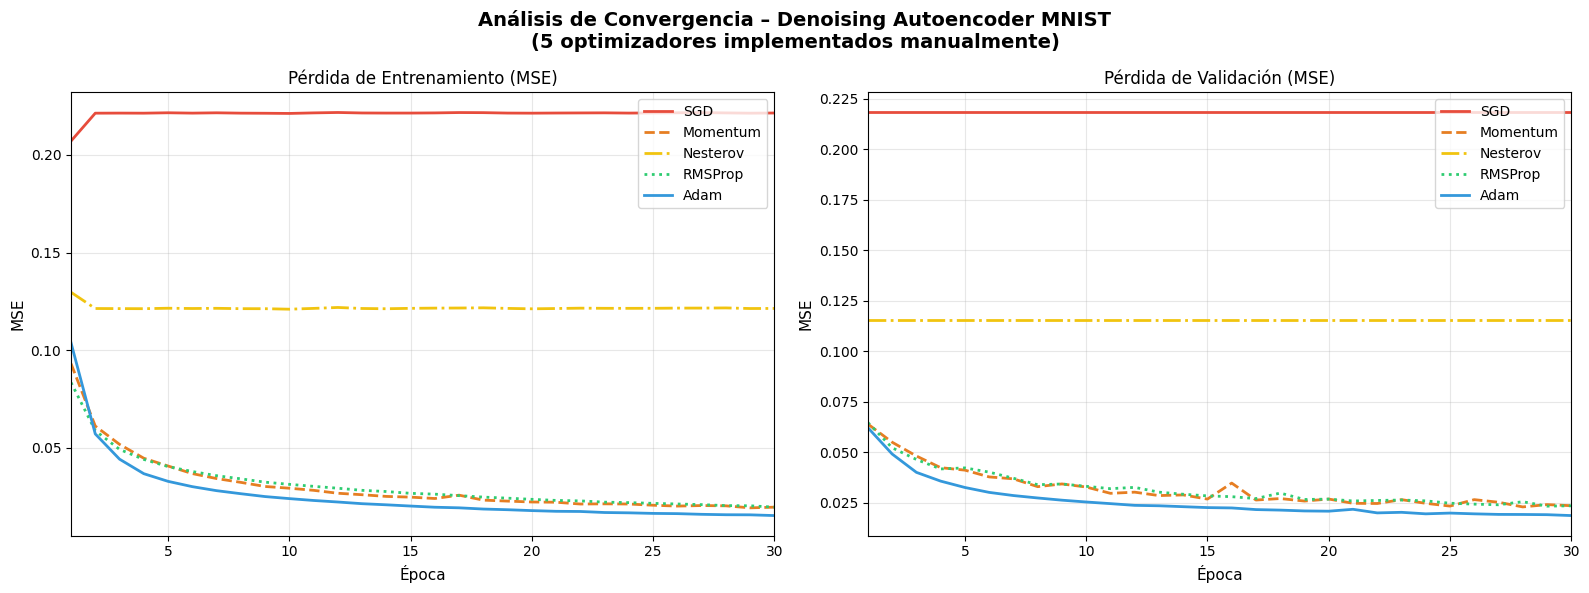

In [17]:
COLORS = {
    'SGD':      '#e74c3c',
    'Momentum': '#e67e22',
    'Nesterov': '#f1c40f',
    'RMSProp':  '#2ecc71',
    'Adam':     '#3498db',
}
LINESTYLES = {
    'SGD':      '-',
    'Momentum': '--',
    'Nesterov': '-.',
    'RMSProp':  ':',
    'Adam':     '-',
}

epochs_ax = np.arange(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Análisis de Convergencia – Denoising Autoencoder MNIST\n'
             '(5 optimizadores implementados manualmente)', fontsize=14, fontweight='bold')

for name, (model, hist, elapsed) in results.items():
    c  = COLORS[name]
    ls = LINESTYLES[name]
    axes[0].plot(epochs_ax, hist['train_loss'], color=c, ls=ls, lw=2, label=name)
    axes[1].plot(epochs_ax, hist['val_loss'],   color=c, ls=ls, lw=2, label=name)

for ax, title, ylabel in zip(
    axes,
    ['Pérdida de Entrenamiento (MSE)', 'Pérdida de Validación (MSE)'],
    ['MSE', 'MSE']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(1, EPOCHS)

plt.tight_layout()

## Comparación de velocidad de convergencia

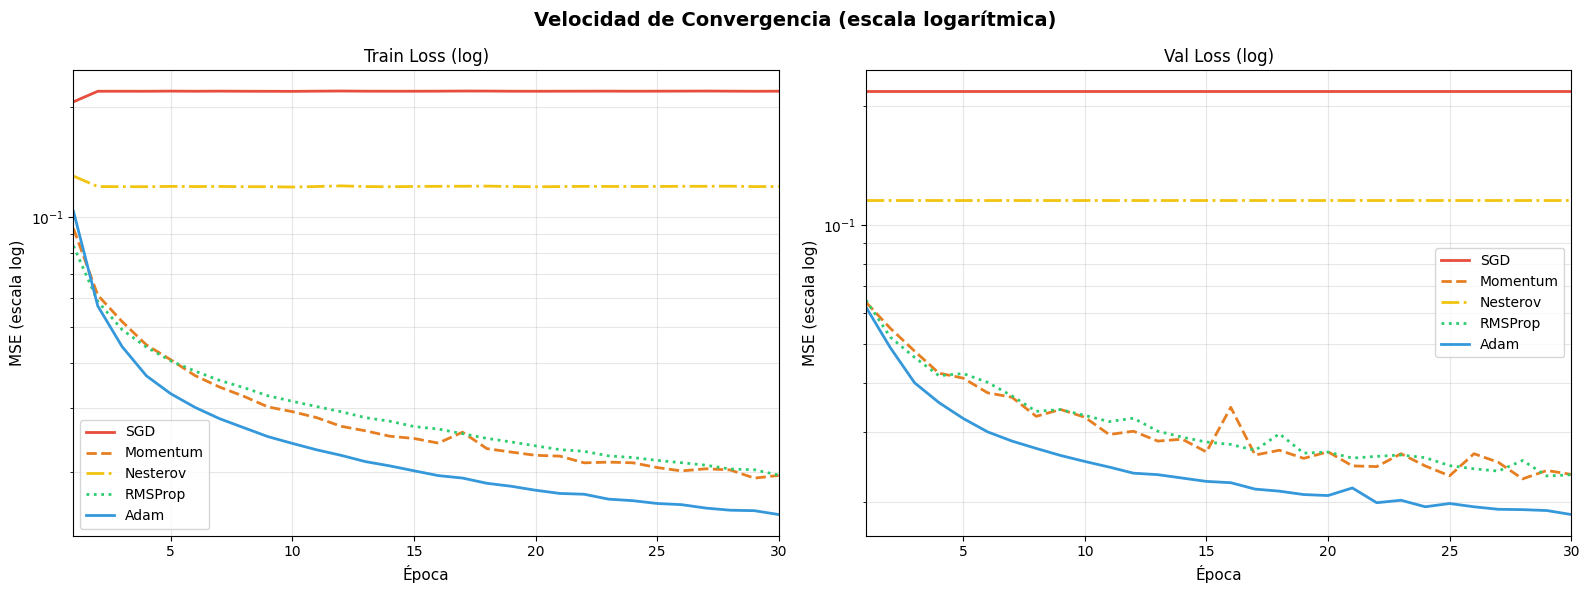

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Velocidad de Convergencia (escala logarítmica)', fontsize=14, fontweight='bold')

for name, (model, hist, elapsed) in results.items():
    c  = COLORS[name]
    ls = LINESTYLES[name]
    axes[0].semilogy(epochs_ax, hist['train_loss'], color=c, ls=ls, lw=2, label=name)
    axes[1].semilogy(epochs_ax, hist['val_loss'],   color=c, ls=ls, lw=2, label=name)

for ax, title in zip(axes, ['Train Loss (log)', 'Val Loss (log)']):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Época', fontsize=11)
    ax.set_ylabel('MSE (escala log)', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim(1, EPOCHS)

plt.tight_layout()
plt.show()

## Tabla resumen de métricas finales

In [20]:
print(f"{'Optimizador':<12} {'Train MSE final':>16} {'Val MSE final':>14} {'Tiempo (s)':>11} {'Épocas p/conv.':>15}")
print('-' * 72)

summary = {}
CONVERGENCE_THRESHOLD = 0.005

for name, (model, hist, elapsed) in results.items():
    train_final = hist['train_loss'][-1]
    val_final   = hist['val_loss'][-1]

    epochs_conv = next((e+1 for e, v in enumerate(hist['val_loss']) if v < CONVERGENCE_THRESHOLD),EPOCHS)

    summary[name] = {
        'train_final': train_final,
        'val_final':   val_final,
        'elapsed':     elapsed,
        'epochs_conv': epochs_conv,
    }

    conv_str = f'{epochs_conv}' if epochs_conv < EPOCHS else f'>{EPOCHS}'
    print(f'{name:<12} {train_final:>16.6f} {val_final:>14.6f} {elapsed:>11.1f} {conv_str:>15}')

Optimizador   Train MSE final  Val MSE final  Tiempo (s)  Épocas p/conv.
------------------------------------------------------------------------
SGD                  0.221469       0.218157       140.8             >30
Momentum             0.019634       0.023474        34.1             >30
Nesterov             0.121398       0.115599        95.0             >30
RMSProp              0.019666       0.023427        37.6             >30
Adam                 0.015338       0.018586        41.8             >30


## Pérdida final y tiempo de entrenamiento

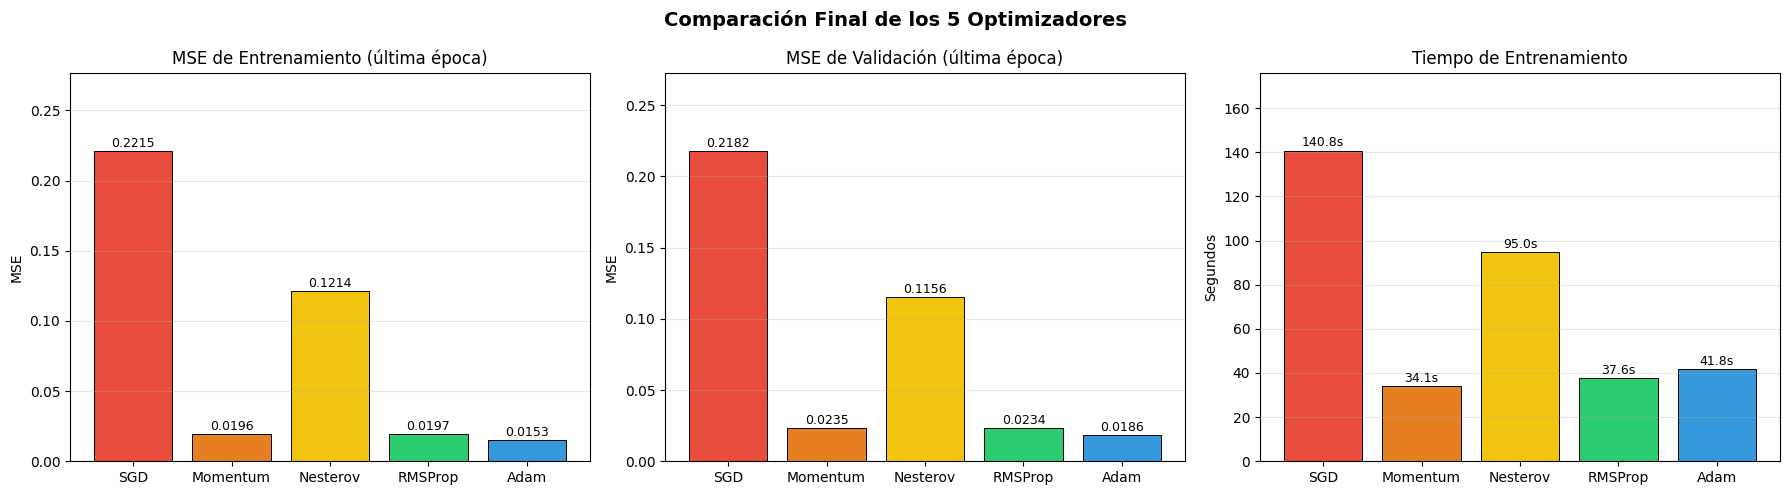

In [22]:
names       = list(results.keys())
val_finals  = [summary[n]['val_final'] for n in names]
train_finals= [summary[n]['train_final'] for n in names]
times       = [summary[n]['elapsed'] for n in names]
colors      = [COLORS[n] for n in names]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparación Final de los 5 Optimizadores', fontsize=14, fontweight='bold')

# Gráfica 1: Train MSE final
bars = axes[0].bar(names, train_finals, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('MSE de Entrenamiento (última época)')
axes[0].set_ylabel('MSE')
axes[0].set_ylim(0, max(train_finals)*1.25)
for bar, v in zip(bars, train_finals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Gráfica 2: Val MSE final
bars = axes[1].bar(names, val_finals, color=colors, edgecolor='black', linewidth=0.7)
axes[1].set_title('MSE de Validación (última época)')
axes[1].set_ylabel('MSE')
axes[1].set_ylim(0, max(val_finals)*1.25)
for bar, v in zip(bars, val_finals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.0005,
                 f'{v:.4f}', ha='center', va='bottom', fontsize=9)

# Gráfica 3: Tiempo de entrenamiento
bars = axes[2].bar(names, times, color=colors, edgecolor='black', linewidth=0.7)
axes[2].set_title('Tiempo de Entrenamiento')
axes[2].set_ylabel('Segundos')
axes[2].set_ylim(0, max(times)*1.25)
for bar, v in zip(bars, times):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{v:.1f}s', ha='center', va='bottom', fontsize=9)

for ax in axes:
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Gráficas de reconstrucción – Original → Con Ruido → Reconstruida

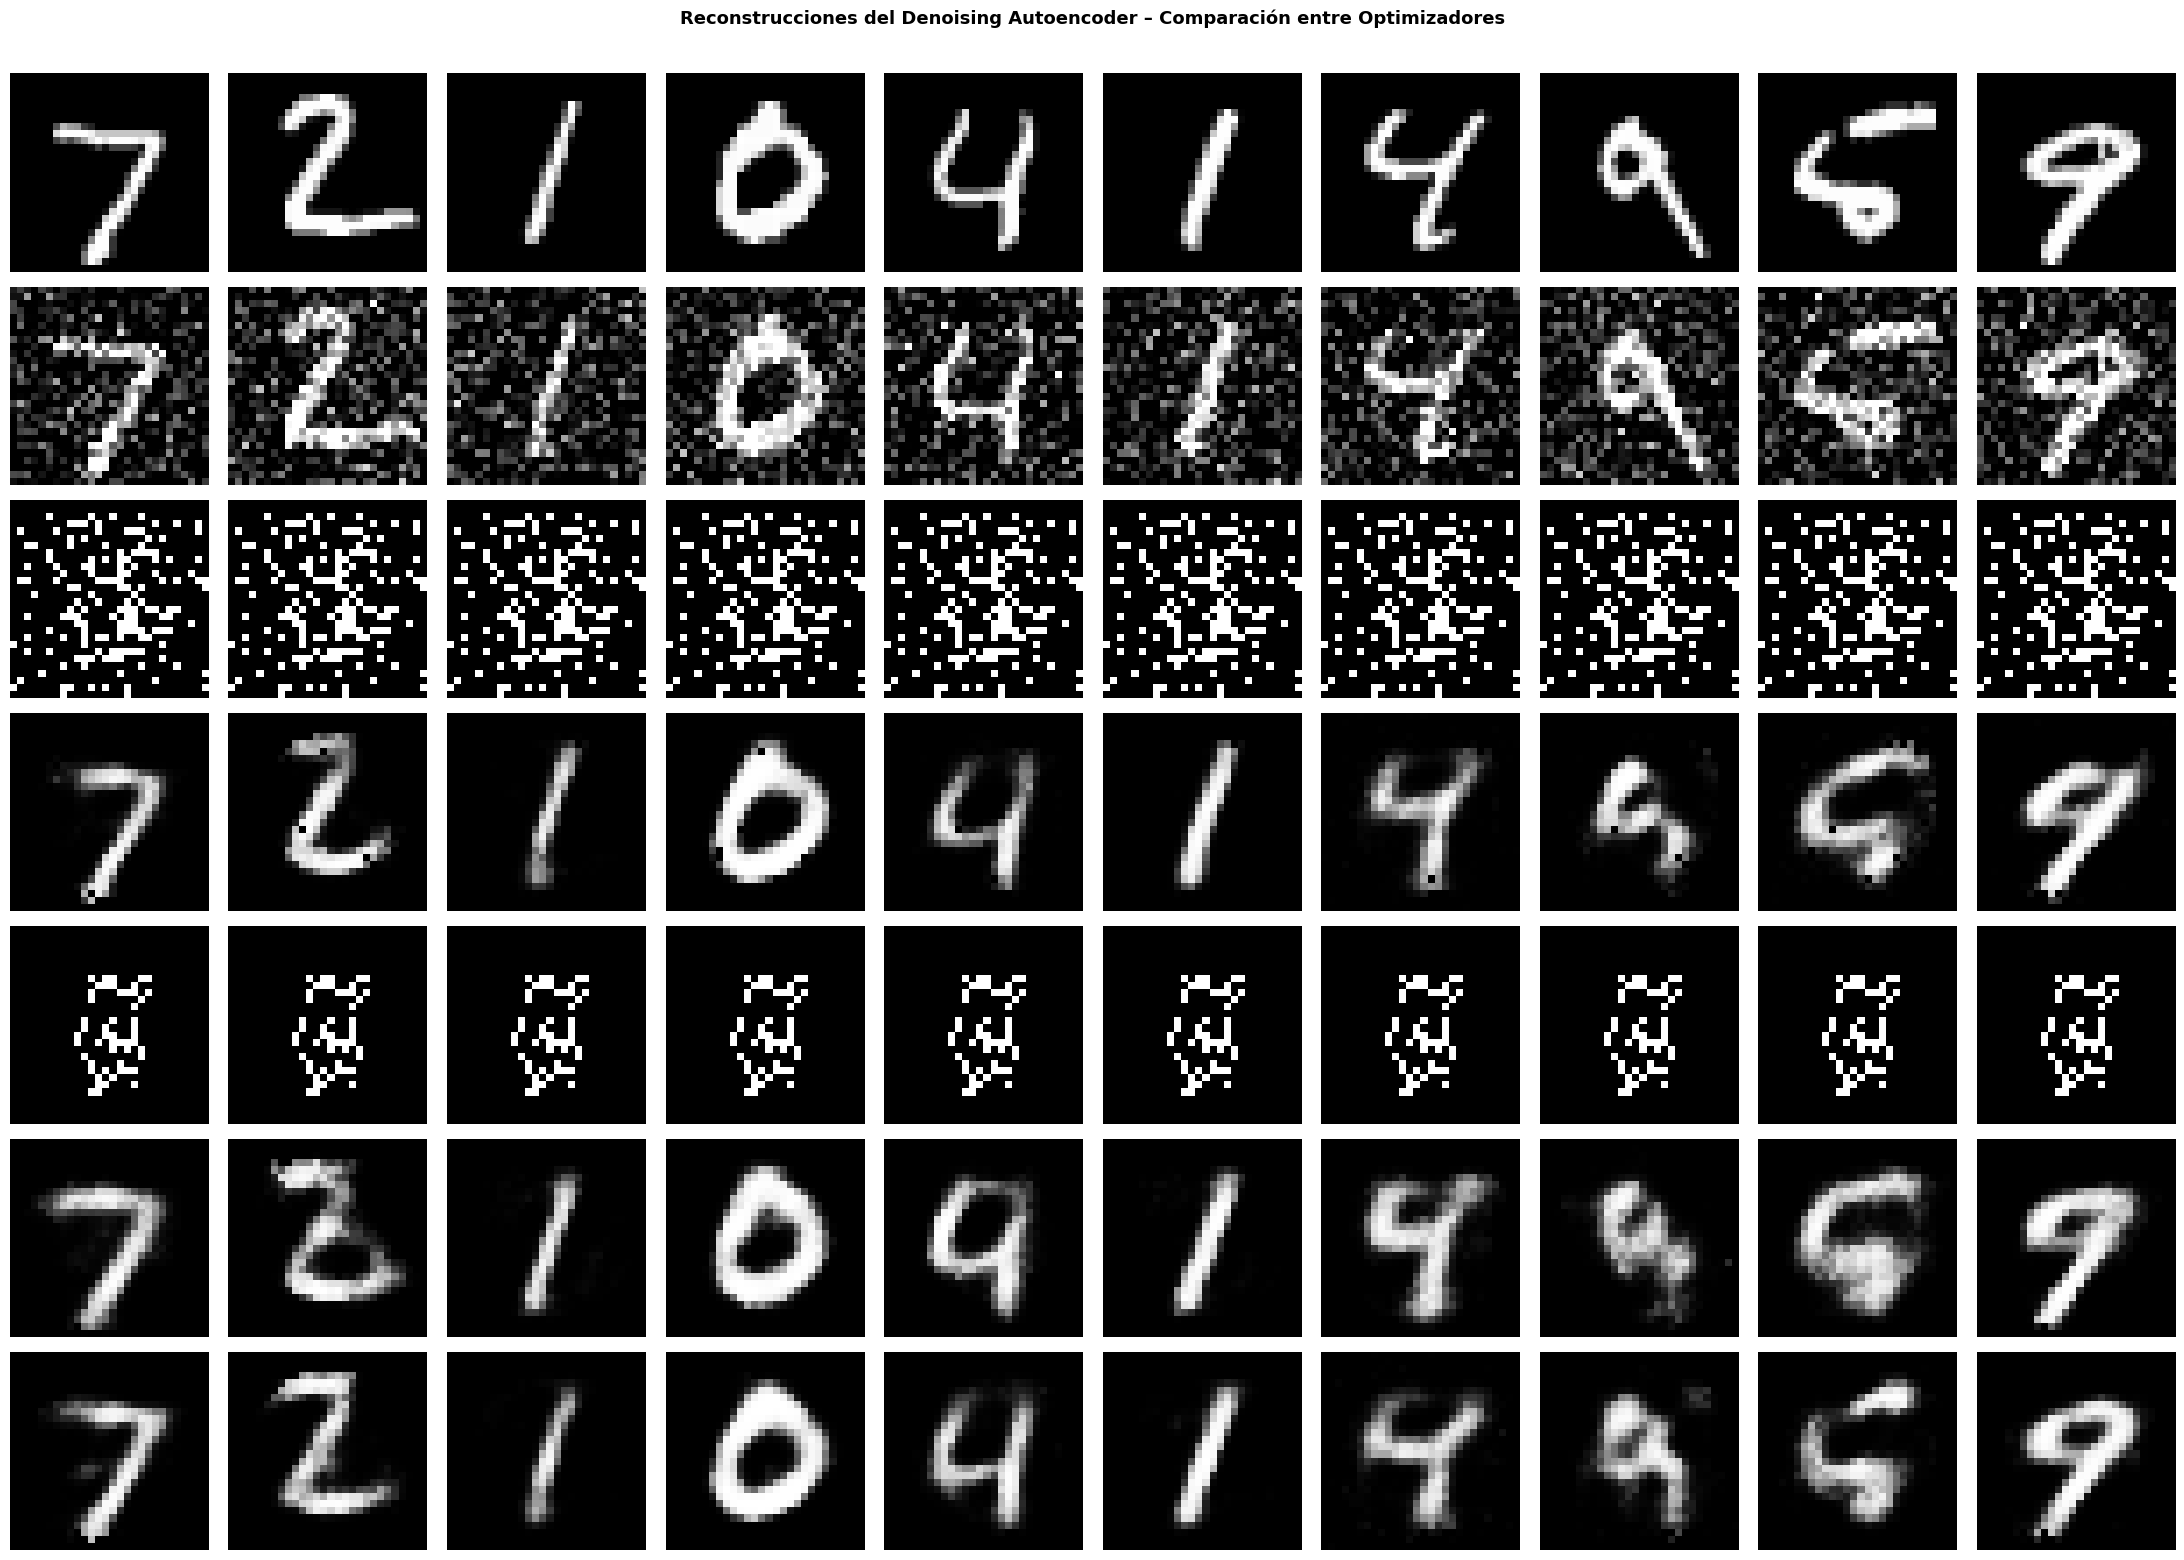

In [25]:
N_SHOW = 10
opt_names = list(results.keys())
n_rows = 2 + len(opt_names)  #og, ruido, + una fila por optimizador

fig, axes = plt.subplots(n_rows, N_SHOW, figsize=(2.2 * N_SHOW, 2.2 * n_rows))
fig.suptitle('Reconstrucciones del Denoising Autoencoder – Comparación entre Optimizadores',
             fontsize=13, fontweight='bold', y=1.01)

row_labels = ['Original\n(limpia)', 'Con ruido\n(entrada)'] + \
             [f'{n}\n(MSE={summary[n]["val_final"]:.4f})' for n in opt_names]

image_sets = [
    x_test[:N_SHOW],
    x_test_noisy[:N_SHOW],
] + [results[n][0].predict(x_test_noisy[:N_SHOW]) for n in opt_names]

row_colors = ['#2c3e50', '#7f8c8d'] + [COLORS[n] for n in opt_names]

for row_idx, (images, label, rc) in enumerate(zip(image_sets, row_labels, row_colors)):
    for col_idx in range(N_SHOW):
        ax = axes[row_idx, col_idx]
        ax.imshow(images[col_idx].reshape(28, 28), cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
        if col_idx == 0:
            ax.set_ylabel(label, fontsize=9, rotation=0,
                          labelpad=80, va='center', color=rc, fontweight='bold')

plt.tight_layout()
plt.show()

## Comparación pixel a pixel – Original vs Reconstruida

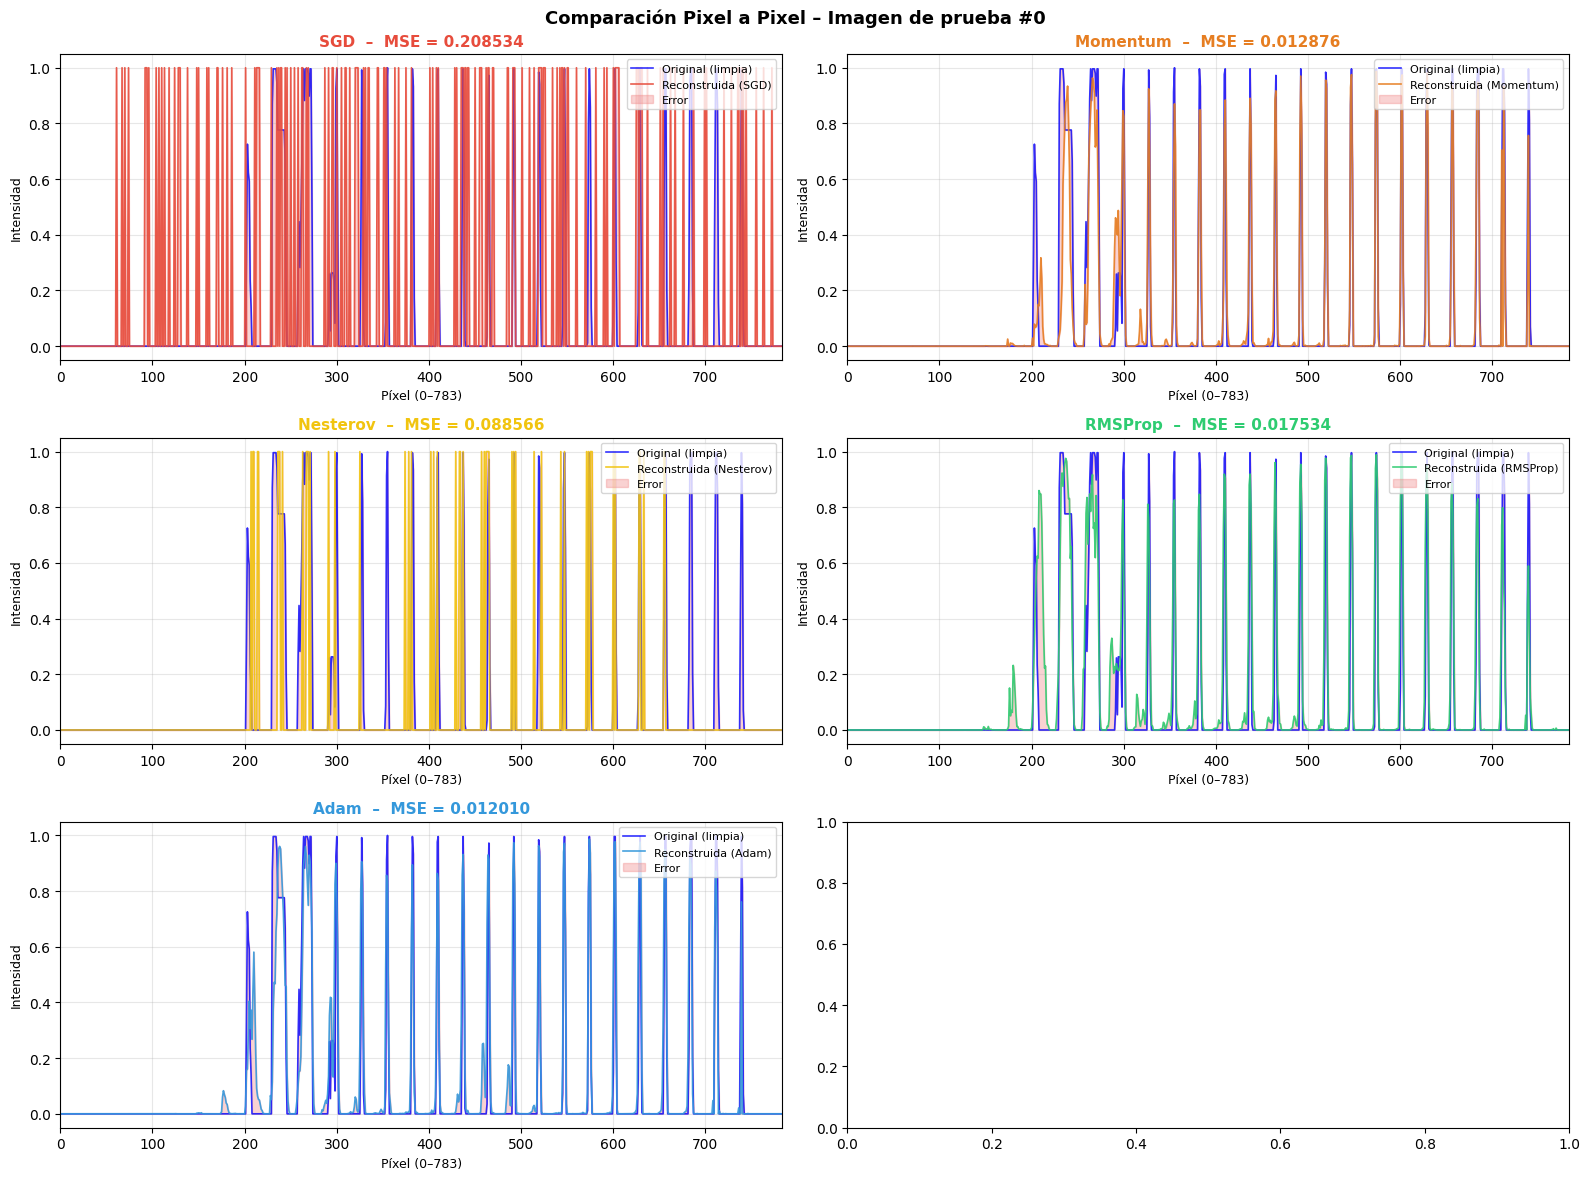

In [26]:
def plot_pixel_comparison(clean, noisy, models_dict, img_idx=0):
    #Gráfica de línea: Original (azul) vs Reconstrucciones de cada optimizador
    fig, axes = plt.subplots(3, 2, figsize=(16, 12))
    fig.suptitle(f'Comparación Pixel a Pixel – Imagen de prueba #{img_idx}',
                 fontsize=13, fontweight='bold')
    axes = axes.flatten()

    clean_vec = clean[img_idx]
    noisy_vec = noisy[img_idx]
    x_pix = np.arange(784)

    for ax_idx, (name, (model, hist, elapsed)) in enumerate(models_dict.items()):
        recon_vec = model.predict(noisy[[img_idx]])[0]
        mse_val   = np.mean((recon_vec - clean_vec)**2)

        ax = axes[ax_idx]
        ax.plot(x_pix, clean_vec,  'b', lw=1.2, alpha=0.8, label='Original (limpia)')
        ax.plot(x_pix, recon_vec,  color=COLORS[name], lw=1.2, alpha=0.9, label=f'Reconstruida ({name})')
        ax.fill_between(x_pix, clean_vec, recon_vec,
                        color='lightcoral', alpha=0.35, label='Error')
        ax.set_title(f'{name}  –  MSE = {mse_val:.6f}', fontsize=11, fontweight='bold',
                     color=COLORS[name])
        ax.set_xlabel('Píxel (0–783)', fontsize=9)
        ax.set_ylabel('Intensidad', fontsize=9)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
        ax.set_xlim(0, 783)
        ax.set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()

plot_pixel_comparison(x_test, x_test_noisy, results, img_idx=0)

## Evaluación con distintos niveles de ruido

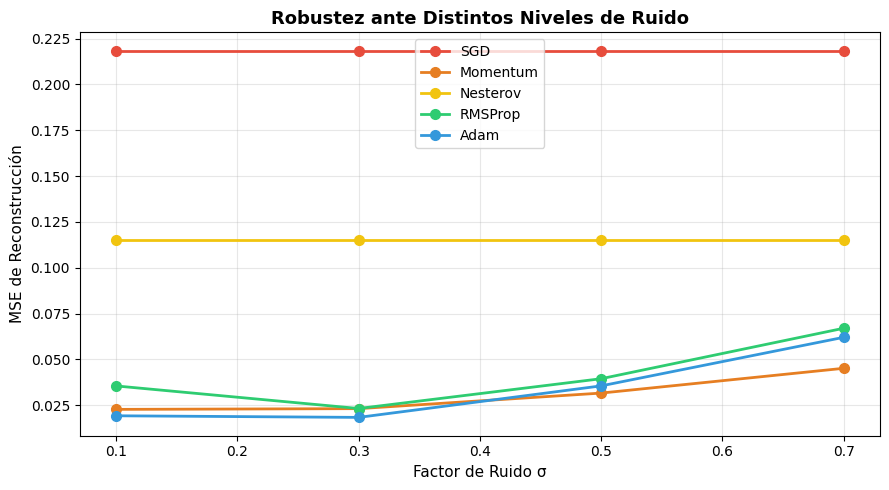


MSE de reconstrucción por nivel de ruido:
Optimizador   σ=0.1  σ=0.3  σ=0.5  σ=0.7
------------------------------------------------------------
SGD           0.21841  0.21841  0.21841  0.21841
Momentum      0.02269  0.02310  0.03159  0.04511
Nesterov      0.11524  0.11524  0.11524  0.11524
RMSProp       0.03548  0.02317  0.03942  0.06695
Adam          0.01920  0.01833  0.03552  0.06200


In [27]:
noise_levels = [0.1, 0.3, 0.5, 0.7]
opt_names    = list(results.keys())

noise_mse = {name: [] for name in opt_names}

for nf in noise_levels:
    x_noisy_nf = add_noise(x_test[:500], nf, seed=99)
    for name, (model, hist, elapsed) in results.items():
        recon = model.predict(x_noisy_nf)
        mse   = np.mean((recon - x_test[:500])**2)
        noise_mse[name].append(mse)

fig, ax = plt.subplots(figsize=(9, 5))
for name in opt_names:
    ax.plot(noise_levels, noise_mse[name], 'o-',
            color=COLORS[name], lw=2, ms=7, label=name)

ax.set_title('Robustez ante Distintos Niveles de Ruido', fontsize=13, fontweight='bold')
ax.set_xlabel('Factor de Ruido σ', fontsize=11)
ax.set_ylabel('MSE de Reconstrucción', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nMSE de reconstrucción por nivel de ruido:')
print(f"{'Optimizador':<12}  " + '  '.join(f'σ={nf}' for nf in noise_levels))
print('-' * 60)
for name in opt_names:
    vals = '  '.join(f'{v:.5f}' for v in noise_mse[name])
    print(f'{name:<12}  {vals}')

## Varianza de la pérdida de validación

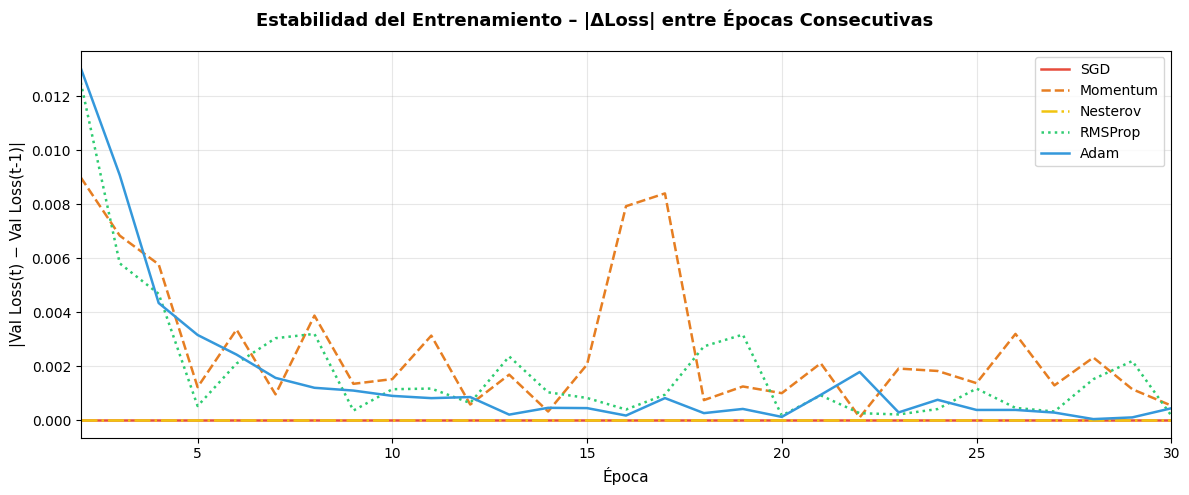

Varianza de las oscilaciones (|ΔLoss|):
  SGD           std=0.000000  max_delta=0.000000
  Momentum      std=0.002466  max_delta=0.008989
  Nesterov      std=0.000000  max_delta=0.000000
  RMSProp       std=0.002444  max_delta=0.012508
  Adam          std=0.002790  max_delta=0.013038


In [28]:
fig, ax = plt.subplots(figsize=(12, 5))
fig.suptitle('Estabilidad del Entrenamiento – |ΔLoss| entre Épocas Consecutivas',
             fontsize=13, fontweight='bold')

for name, (model, hist, elapsed) in results.items():
    delta = np.abs(np.diff(hist['val_loss']))
    ax.plot(np.arange(2, EPOCHS+1), delta,
            color=COLORS[name], ls=LINESTYLES[name], lw=1.8, label=name)

ax.set_xlabel('Época', fontsize=11)
ax.set_ylabel('|Val Loss(t) − Val Loss(t-1)|', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(2, EPOCHS)
plt.tight_layout()
plt.show()

print('Varianza de las oscilaciones (|ΔLoss|):')
for name, (model, hist, elapsed) in results.items():
    delta = np.abs(np.diff(hist['val_loss']))
    print(f'  {name:<12}  std={delta.std():.6f}  max_delta={delta.max():.6f}')